In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
x = np.array([1,2,3,4,5,6]).reshape(-1,1)
y = np.array([1.5,3.5,6,8.5,11,14])

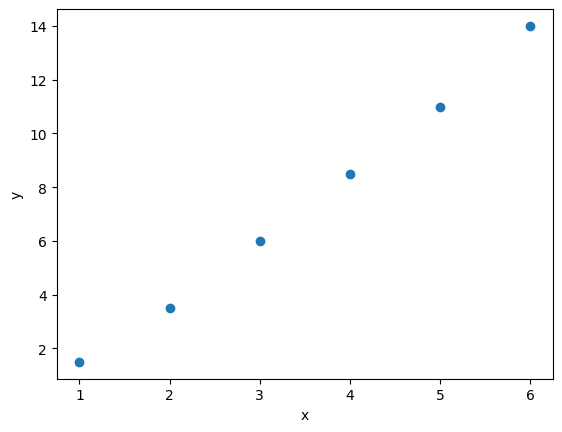

In [3]:
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [16]:
def polynomial_features(x, degree):
    X_poly = x.copy()
    
    for d in range(2, degree+1):
        X_poly = np.hstack((X_poly, x**d))
        
    return X_poly


In [42]:
X_poly = polynomial_features(x, degree=2)

In [43]:
mean = np.mean(X_poly, axis=0)
std = np.std(X_poly, axis=0)

X_poly = (X_poly - mean) / std


In [44]:
m, n = X_poly.shape

w = np.zeros(n)
b = 0
alpha = 0.01
iterations = 1000

In [45]:
def predict(x,w,b):
    return np.dot(x,w) + b

In [46]:
def compute_cost(x,y,w,b):
    m = len(y)
    predictions = predict(x,w,b)
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost 

In [47]:
def compute_gradient(x,y,w,b):
    m, n = x.shape
    predictions = predict(x,w,b)
    error = predictions - y
    
    dj_dw = (1/m) * np.dot(x.T,error)
    dj_db = (1/m) * np.sum(error)
    
    return dj_dw, dj_db

In [48]:
def gradient_descent(x,y,w,b,alpha,iterations):
    cost_history = []
    
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x,y,w,b)
        
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost_history.append( compute_cost(x,y,w,b))
        
    return w, b, cost_history    

In [49]:
w, b, cost_history = gradient_descent(X_poly, y, w, b, alpha, iterations)


In [50]:
y_pred = predict(X_poly, w, b)

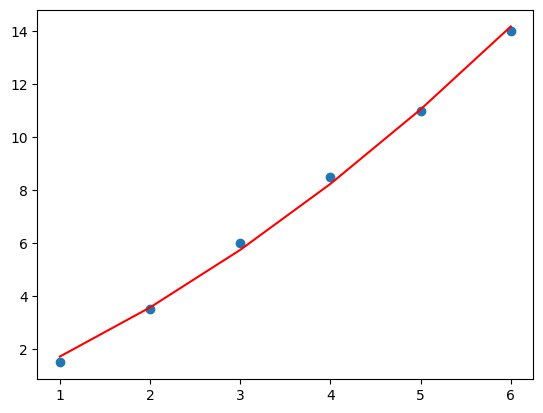

In [51]:
plt.scatter(x[:,0],y)
plt.plot(x[:,0],y_pred,color = 'red')
plt.show()

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)


In [53]:
w,b,J_history = gradient_descent(X_train,y_train,w,b,alpha,iterations)
#Trains the linear regression model using the training data (x_train and y_train) by performing gradient descent
# optimization to find the optimal parameters w and b. The cost history J_history is also returned for visualization of the convergence of the algorithm.


In [54]:
y_pred_test = predict(X_test, w, b)
#Predicts the values of y for the test set (x_test) using the optimized parameters w and b obtained from training the
#model on the training set. The predicted values y_pred_test can be used to evaluate the performance of the model on unseen data.


In [55]:
from sklearn.metrics import r2_score

In [56]:
r2_test = r2_score(y_test, y_pred_test) #calculates the R-squared score for the test set using the actual values of y_test and the predicted values y_pred_test, which can be used to evaluate the performance of the linear regression model on unseen data.
print("Test R2 Score:",r2_test)

Test R2 Score: 0.6291988931886967
